# WEEK 5: ADVANCED MACHINE LEARNING
The objective of this notebook is to explore advanced machine learning algorithms and learn how to improve model performance

In [1]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## House Prediction

In [2]:
# load dataset
df = pd.read_csv("Cleaned_Housing_Dataset")
# data preview
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
# Explore Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [4]:
df.duplicated().sum()

np.int64(0)

## Encode Categorical Variables

In [5]:
df = pd.get_dummies(df, drop_first=True)

In [6]:
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


## Define features

In [7]:
X = df.drop("price", axis=1)

y = df["price"]

## Split train and test sets 

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Feature Scaling

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## A. Baseline Model: Linear Regression

In [10]:
lr = LinearRegression()
# fit
lr.fit(X_train_scaled, y_train)
# make predictions
lr_pred = lr.predict(X_test_scaled)

### Calculate Evaluate Metrics

In [11]:
def evaluate(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    mse = mean_squared_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, y_pred)
    
    return  mae, mse, rmse, r2

### Evaluate Model

In [12]:
lr_results = evaluate(y_test, lr_pred)

print(lr_results)

(970043.4039201642, 1754318687330.6682, np.float64(1324506.9600914402), 0.6529242642153175)


## B. Advanced Machine Learning Models
### 1. Decision Tree

In [13]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_results = evaluate(y_test, dt_pred)

print(dt_results)

(1195266.0550458715, 2642802637614.6787, np.float64(1625669.904259373), 0.4771459275854347)


### 2. Random Forest

In [14]:
rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_results = evaluate(y_test, rf_pred)

print(rf_results)

(1021546.0353211008, 1961585044320.3433, np.float64(1400565.9728553821), 0.611918531405699)


### 3. Gradient Boosting

In [15]:
gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

gb_results = evaluate(y_test, gb_pred)

print(gb_results)

(959748.9636349058, 1688403924777.5098, np.float64(1299385.9799064747), 0.66596489068611)


## C. Hyperparameter Tuning

In [16]:
# Tune Random Forest
param_grid = {

    'n_estimators': [100, 200],

    'max_depth': [5, 10, 20],

    'min_samples_split': [2, 5]

}

### Grid Search

In [17]:
grid = GridSearchCV(

    estimator=RandomForestRegressor(random_state=42),

    param_grid=param_grid,

    cv=5,

    scoring='r2',

    n_jobs=-1

)

grid.fit(X_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


### Best Parameters

In [18]:
grid.best_params_

{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}

### Best model

In [19]:
best_rf = grid.best_estimator_

best_pred = best_rf.predict(X_test)

best_results = evaluate(y_test, best_pred)

print(best_results)

(1035775.2828831404, 2019874102920.6267, np.float64(1421222.7492270966), 0.6003865799717936)


## D. Comparison Table

In [20]:
comparison = pd.DataFrame({

    "Model": [

        "Linear Regression(Baseline)",

        "Decision Tree",

        "Random Forest",

        "Gradient Boosting",

        "Tuned Random Forest"

    ],

    "MAE": [

        lr_results[0],

        dt_results[0],

        rf_results[0],

        gb_results[0],

        best_results[0]

    ],

    "MSE": [

        lr_results[1],

        dt_results[1],

        rf_results[1],

        gb_results[1],

        best_results[1]

    ],

    "RMSE": [

        lr_results[2],

        dt_results[2],

        rf_results[2],

        gb_results[2],

        best_results[2]

    ],

    "R² Score": [

        lr_results[3],

        dt_results[3],

        rf_results[3],

        gb_results[3],

        best_results[3]

    ]

})

comparison

,Model,MAE,MSE,RMSE,R² Score
0,Linear Regression(Baseline),9.700434e+05,1.754319e+12,1.324507e+06,0.652924
1,Decision Tree,1.195266e+06,2.642803e+12,1.625670e+06,0.477146
2,Random Forest,1.021546e+06,1.961585e+12,1.400566e+06,0.611919
3,Gradient Boosting,9.597490e+05,1.688404e+12,1.299386e+06,0.665965
4,Tuned Random Forest,1.035775e+06,2.019874e+12,1.421223e+06,0.600387


## Visualizations
### i. R² Score Comparison

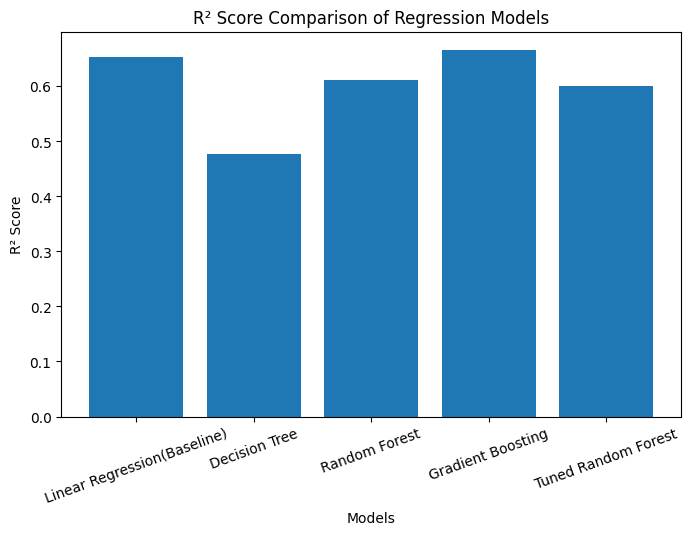

In [21]:
models = comparison["Model"]
r2_scores = comparison["R² Score"]

plt.figure(figsize=(8,5))
plt.bar(models, r2_scores)
plt.title("R² Score Comparison of Regression Models")
plt.xlabel("Models")
plt.ylabel("R² Score")
plt.xticks(rotation=20)
plt.show()

The bar chart compares the R² Scores of all regression models. A higher R² Score indicates that the model explains a greater proportion of the variance in house prices. Gradient Boosting achieved the highest R² Score, making it the best-performing model.

### ii. RMSE Comparison

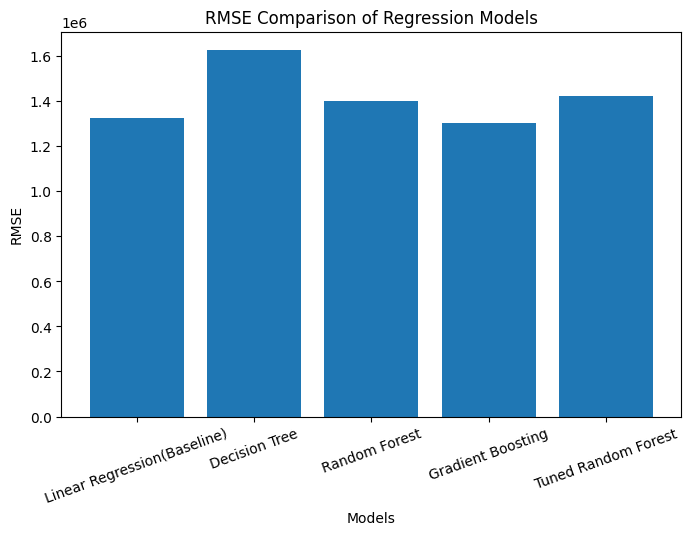

In [22]:
plt.figure(figsize=(8,5))
plt.bar(models, comparison["RMSE"])
plt.title("RMSE Comparison of Regression Models")
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.show()

The RMSE comparison shows the average prediction error for each model. Lower RMSE values indicate better predictive accuracy. Gradient Boosting produced the lowest RMSE, demonstrating the smallest prediction errors among all models.

### iii. Actual vs Predicted Values (Best Model)

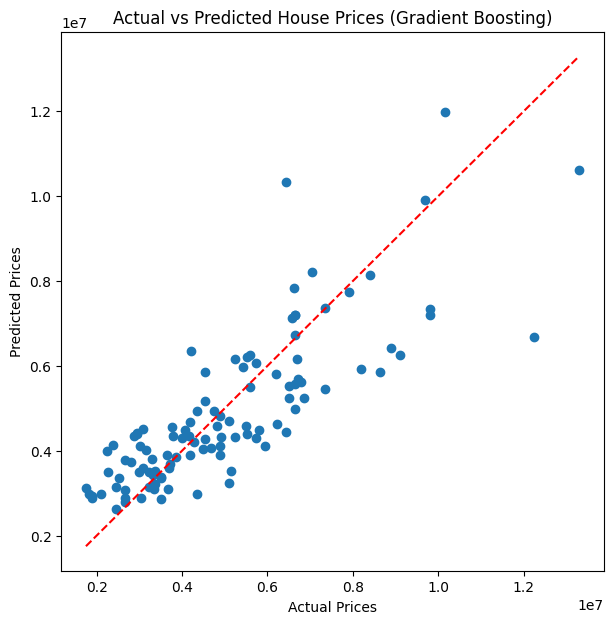

In [23]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, gb_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices (Gradient Boosting)")
plt.show()

### Interpretation

The scatter plot compares the actual house prices with those predicted by the Gradient Boosting model. Points closer to the diagonal line represent more accurate predictions. The clustering of points around the line indicates that the model performs well in predicting house prices.

### iv. Feature Importance

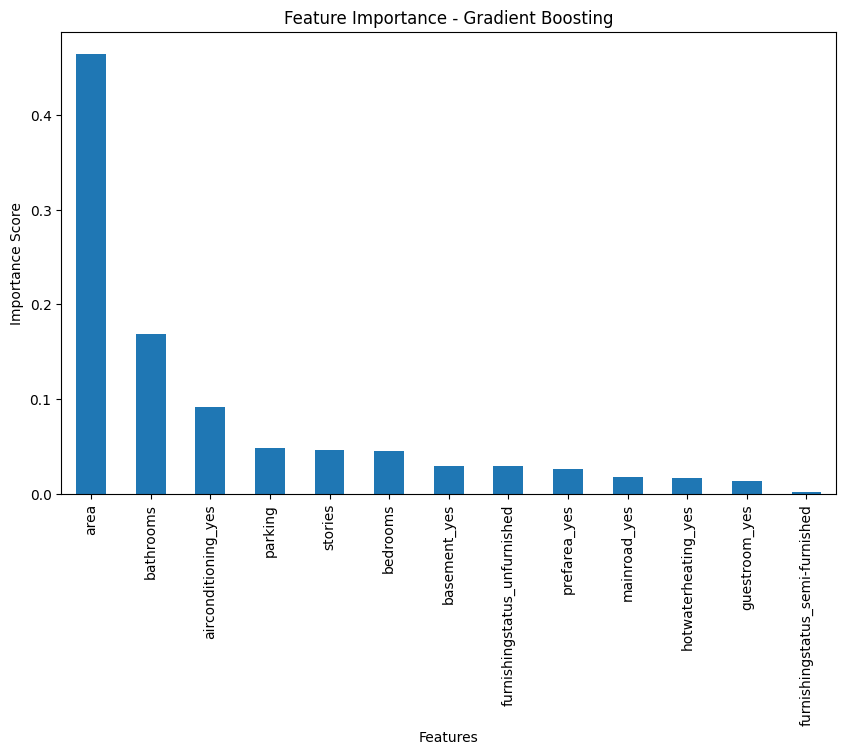

In [24]:
importance = pd.Series(
    gb.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance.plot(kind='bar')
plt.title("Feature Importance - Gradient Boosting")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=90)
plt.show()

The feature importance chart illustrates the relative contribution of each feature to the Gradient Boosting model. Features with higher importance scores have a greater influence on predicting house prices, providing insights into the factors that most affect property values.

## Conclusion

In this project, five regression models were developed and evaluated to predict house prices: Linear Regression, Decision Tree, Random Forest, Gradient Boosting, and a Tuned Random Forest. Model performance was assessed using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and the R² Score.

Among all the models, the **Gradient Boosting Regressor** achieved the best overall performance, recording the **lowest MAE (959,749)**, the **lowest RMSE (1,299,386)**, and the **highest R² Score (0.6660)**. These results indicate that it produced the most accurate predictions and explained approximately **66.6%** of the variation in house prices.

Although hyperparameter tuning was applied to the Random Forest model using **GridSearchCV**, the tuned model performed slightly worse than the original Random Forest. This demonstrates that hyperparameter tuning does not always improve model performance and that the effectiveness of tuning depends on selecting appropriate parameter ranges and the characteristics of the dataset.

Overall, **Gradient Boosting** was identified as the best-performing model because it learns iteratively by correcting the errors of previous trees, enabling it to capture complex patterns in the housing data more effectively than the other models. Therefore, it is the most suitable model for predicting house prices in this project.